<a href="https://colab.research.google.com/github/jawaadjariwala/Aramark/blob/main/03_concentration_and_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Concentration & Risk Analysis

**Phase:** 3 (from the project plan)

**Inputs:** `aramark_spend.agg_distributor_group`, `agg_distributor_state`, `raw_spend`
**Outputs:** HHI by state, top-N share metrics, manufacturer concentration, and a consolidated risk scorecard view (`agg_state_risk_scorecard`) for Power BI.

## Why concentration matters

Notebook 02 showed MASTER DISTRIBUTOR carries ~53% of all Aramark spend and is the #1 distributor in every US state. That's a headline, but it's not yet a *risk* metric. This notebook quantifies:

- **How dependent** each state is on a handful of suppliers (HHI, top-N share)
- **Where** the dependency is dangerous enough to flag (DOJ concentration thresholds)
- **Upstream risk** — which manufacturers dominate, since MASTER DISTRIBUTOR is a pass-through channel that hides the real source concentration


## Working Feature Set — Evolution from 11 to 15 Columns

In Notebook 01 we pruned the original 23 columns down to **11 clean analytical columns**. That pruning was the right call for in-memory pandas chunking — every extra column cost memory on every chunk.

Once we migrated to BigQuery (Notebook 02), the calculus changed. The entire 23-column table is stored once; adding a column to a query costs nothing. So we selectively bring back fields when the analysis needs them, while keeping our original drop decisions documented.

### Columns in use (15)

| Column | Phase added | Purpose |
|---|---|---|
| `year_month` | 01 | Monthly time grain |
| `business_entity_type` | 01 | GPO vs Managed Services |
| `state`, `city` | 01 | Geographic rollups |
| `customer_market_segment_id` | 01 | Industry segment |
| `number_of_rooms` | 01 | Operational scale bands |
| `distributor_group` | 01 | Primary supplier grouping |
| `category_level_1`, `category_level_2` | 01 | Product hierarchy |
| `spend_random_factor` | 01 | Spend proxy (USD, randomized) |
| `category_level_3`, `category_level_4` | 02 | Drill-down for Power BI hierarchy |
| `customer_id` | 02 | `COUNT(DISTINCT customer_id)` in segment & room band analysis |
| `manufacturer_id` | **03** | Upstream concentration / risk analysis |

### Columns dropped (8) — rationale unchanged

| Dropped column | Why |
|---|---|
| `year_name` | Constant (2025) |
| `country` | Constant (US) |
| `client_id` | High-cardinality identifier, no aggregation value |
| `customer_brand_id` | ~21% missing |
| `customer_brand_parent_id` | ~73% missing |
| `zip` | Redundant with state / city |
| `ecommerce_status` | ~88% missing |
| `distributor_id` | Redundant with `distributor_group` |
| `category_id` | Redundant with category levels |

**Note on `manufacturer_id`:** ~34% missing (per Notebook 01). We include it in Phase 3 with an explicit caveat — upstream concentration is too important to skip, and 66% coverage is directionally sound for relative risk comparisons across states.


## Workflow Note — View Creation in This Notebook

Notebook 02 materialized 14 aggregation views as a single batch at the end of the notebook. That was the right place for anything we already knew we needed.

For Phase 3 we need one additional view — `agg_distributor_category` (distributor × Category L1) — that wasn't part of the Notebook 02 cross-cuts. Rather than going back and modifying the completed Notebook 02, we create it here.


### Setup

We connect to BigQuery from Colab using the same authenticated Google account that owns the `raw_spend` table. Three things happen here:

1. **`auth.authenticate_user()`** — Colab's standard OAuth flow. Produces a token the BigQuery client can use.
2. **`bigquery.Client(project=PROJECT_ID)`** — creates a reusable client object that talks to the BigQuery API. All queries in this notebook go through this client.
3. **`view()` helper** — a Python function that wraps view names in backticks and qualifies them with project + dataset. This keeps every SQL string below cleaner (we write `{view('agg_state')}` instead of repeating the long path 20 times).

No data is loaded yet — everything below runs server-side in BigQuery; we only pull down the final result rows to display.


In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "big-data-algorithms-493312"
DATASET_ID = "aramark_spend"

client = bigquery.Client(project=PROJECT_ID)

# Shortcut: fully-qualified view names
def view(name):
    return f"`{PROJECT_ID}.{DATASET_ID}.{name}`"

print("Connected.")

Connected.


### Creating the `agg_distributor_category` view

A **BigQuery view** is a stored SQL query that behaves like a table: every time you query it, BigQuery re-runs the underlying SQL against the current state of `raw_spend`. Views cost no storage and can never be stale.

**Why this view isn't in Notebook 02.** Notebook 02 materialized 14 views covering the aggregations we already knew we needed. Phase 3 introduces one new cut — distributor spend broken down by Category L1 — that we didn't need until now.

**What the SQL does, line by line:**

- `CREATE OR REPLACE VIEW ... AS` — defines (or overwrites) the view.
- `GROUP BY category_level_1, distributor_group` — we aggregate at the (category, distributor) pair, giving us one row per combination.
- `ROUND(SUM(spend_random_factor), 0)` — sum the spend proxy for each pair; rounding strips decimal noise since the proxy is randomized.
- `COUNT(*)` — how many transactions rolled into that pair.
- `WHERE distributor_group IS NOT NULL` — drops the ~62K transactions where distributor is unknown, so they don't create a phantom "null" competitor in later HHI math.


In [2]:
# New view for this notebook: distributor spend within each Category L1.
# Supports the category-level HHI calculation later.
ddl = f"""
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.agg_distributor_category` AS
SELECT
  category_level_1,
  distributor_group,
  ROUND(SUM(spend_random_factor), 0) AS total_spend,
  COUNT(*)                           AS transaction_count
FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend`
WHERE distributor_group IS NOT NULL
GROUP BY category_level_1, distributor_group
"""
client.query(ddl).result()
print("Created view: agg_distributor_category")


Created view: agg_distributor_category


## 3.1 — National Concentration Baseline

Before we look at states, we need the national picture. Two questions:

1. What share of total spend goes through the top 1 / 3 / 5 / 10 distributor groups?
2. How unequal is the distribution of spend across all distributor groups? (Gini coefficient, visualized with a Lorenz curve)


### Top-N share: what it measures

Top-N share is the simplest concentration metric: *what percentage of total spend flows through the N largest distributors?* In a perfectly competitive market with many equal players, the top-1 share would be small. In a monopoly, it would be 100%.

We compute top-1, top-3, top-5, and top-10 shares for the national distributor base.

$$\text{Top-N share} = \frac{\sum_{i=1}^{N} \text{spend}_i}{\sum_{i=1}^{\text{all}} \text{spend}_i} \times 100$$

### How the SQL builds this

1. **CTE `ranked`** — ranks distributors by total spend descending using `ROW_NUMBER()`. Also computes `grand_total` via `SUM(...) OVER ()` (a window function with no `PARTITION BY` sums across the whole table).
2. **Four `SELECT` statements joined with `UNION ALL`** — each one sums spend for rows where `rn <= N`, divides by the grand total, and labels it `'Top N'`.
3. **`ORDER BY pct_of_total_spend`** — orders the final buckets ascending so the progression is visible at a glance.

A window function lets us attach aggregate values (like the grand total) to every row without a second pass — faster and cleaner than a self-join.


In [3]:
import pandas as pd

sql = f"""
WITH ranked AS (
  SELECT
    distributor_group,
    total_spend,
    SUM(total_spend) OVER ()                                  AS grand_total,
    ROW_NUMBER() OVER (ORDER BY total_spend DESC)             AS rn
  FROM {view('agg_distributor_group')}
  WHERE distributor_group IS NOT NULL
)
SELECT
  'Top 1'  AS bucket, ROUND(100 * SUM(CASE WHEN rn <= 1  THEN total_spend END) / MAX(grand_total), 2) AS pct_of_total_spend FROM ranked
UNION ALL SELECT 'Top 3',  ROUND(100 * SUM(CASE WHEN rn <= 3  THEN total_spend END) / MAX(grand_total), 2) FROM ranked
UNION ALL SELECT 'Top 5',  ROUND(100 * SUM(CASE WHEN rn <= 5  THEN total_spend END) / MAX(grand_total), 2) FROM ranked
UNION ALL SELECT 'Top 10', ROUND(100 * SUM(CASE WHEN rn <= 10 THEN total_spend END) / MAX(grand_total), 2) FROM ranked
ORDER BY pct_of_total_spend
"""
national_topn = client.query(sql).to_dataframe()
national_topn


,bucket,pct_of_total_spend
0,Top 1,54.30
1,Top 3,65.63
2,Top 5,74.12
3,Top 10,86.89


### Lorenz curve & Gini coefficient — concept

The top-N numbers tell us about the leaders, but they don't describe the full shape of inequality. For that we use:

**Lorenz curve.** Sort all distributors from smallest to largest. Plot cumulative % of distributors (x-axis) vs cumulative % of spend (y-axis). If every distributor got an equal share, the curve would be the 45° line. The more it bows downward below that line, the more unequal the distribution.

**Gini coefficient.** A single number that summarizes the Lorenz curve:

$$G = 1 - 2 \int_0^1 L(x)\,dx$$

where $L(x)$ is the Lorenz curve. The integral is the area *under* the curve. Since a perfectly equal distribution gives area = 0.5 (triangle), $G = 0$. A monopoly gives area ≈ 0, so $G ≈ 1$.

Interpretation rule of thumb:
- **0.0 – 0.3** — relatively equal
- **0.3 – 0.5** — moderate inequality
- **0.5 – 0.8** — high inequality
- **> 0.8** — extreme concentration

### Code walkthrough

- Pull all distributor groups sorted **ascending** by spend (required for the Lorenz construction).
- `np.cumsum(spend) / spend.sum()` → cumulative share of spend; values rise from near-0 to 1.
- `np.arange(1, n+1) / n` → cumulative % of distributors.
- `np.trapz(cum_share, cum_pct)` → trapezoidal numerical integration of the area under the Lorenz curve.
- `gini = 1 - 2 * area` applies the formula above.

The plot shades the "inequality gap" between the 45° line and the actual Lorenz curve — a visual proxy for Gini.


/tmp/ipykernel_47486/3630495552.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_share, cum_pct)


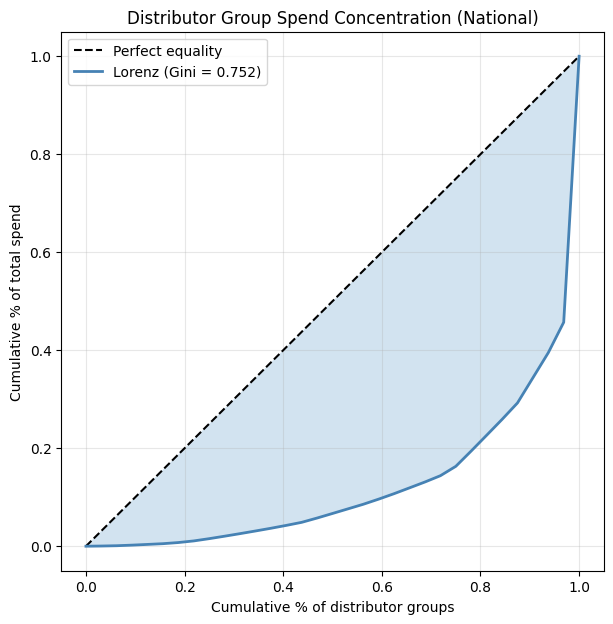

Gini coefficient: 0.752
(0 = perfectly equal distribution, 1 = total concentration in one distributor)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Pull all distributor groups sorted ascending for Lorenz curve
sql = f"""
SELECT distributor_group, total_spend
FROM {view('agg_distributor_group')}
WHERE distributor_group IS NOT NULL
ORDER BY total_spend ASC
"""
dist_df = client.query(sql).to_dataframe()

spend = dist_df["total_spend"].to_numpy()
n = len(spend)
cum_share = np.cumsum(spend) / spend.sum()
cum_pct   = np.arange(1, n + 1) / n

# Gini = 1 - 2 * area under Lorenz curve (trapezoidal)
gini = 1 - 2 * np.trapz(cum_share, cum_pct)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", label="Perfect equality")
ax.plot(np.concatenate(([0], cum_pct)), np.concatenate(([0], cum_share)),
        color="steelblue", linewidth=2, label=f"Lorenz (Gini = {gini:.3f})")
ax.fill_between(np.concatenate(([0], cum_pct)), np.concatenate(([0], cum_share)),
                np.concatenate(([0], cum_pct)), alpha=0.2)
ax.set_xlabel("Cumulative % of distributor groups")
ax.set_ylabel("Cumulative % of total spend")
ax.set_title("Distributor Group Spend Concentration (National)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Gini coefficient: {gini:.3f}")
print(f"(0 = perfectly equal distribution, 1 = total concentration in one distributor)")


## 3.2 — State-Level Concentration (HHI + Top-N)

The **Herfindahl-Hirschman Index (HHI)** is the standard concentration metric used by the US Department of Justice in antitrust reviews. It is the sum of squared market shares (expressed as percentages, so HHI is on a 0–10,000 scale):

$$HHI = \sum_{i=1}^{N} s_i^2$$

DOJ thresholds:
- **< 1,500** — competitive market
- **1,500 – 2,500** — moderate concentration
- **> 2,500** — high concentration (flag for risk)

We compute state-level HHI on distributor spend, along with top-1, top-3, and top-5 shares for the procurement narrative.

**Data quality filter.** The `state` column has three anomalous values we exclude: `GEORGIA` (full name, 2 rows — likely a data entry error for `GA`), `AB` (1 row, Canadian province — violates the US-only scope), and `PR` (2,082 rows — Puerto Rico, kept but flagged in the scorecard).


### SQL walkthrough — computing state-level HHI

HHI needs each competitor's **share squared** within each state, then those squares summed. The challenge in SQL is computing "share within group" — that's where window functions do the heavy lifting.

**CTE `shares` — computes three things per (state, distributor) row:**

- `100.0 * total_spend / SUM(total_spend) OVER (PARTITION BY state)` — the distributor's share of that state's spend, as a percentage. `OVER (PARTITION BY state)` tells BigQuery to compute the sum *within* each state, not across all states.
- `ROW_NUMBER() OVER (PARTITION BY state ORDER BY total_spend DESC)` — assigns rank 1 to the top distributor in each state, 2 to the next, and so on.
- The `WHERE` clause drops the two malformed state values (`GEORGIA`, `AB`) identified in Notebook 02.

**Outer `SELECT` — rolls up to one row per state:**

- `SUM(POW(share_pct, 2))` — the HHI formula literally: sum of squared market shares.
- `MAX(CASE WHEN rn = 1 THEN share_pct END)` — extracts the top-1 share. We use `MAX` because only one row per state has `rn = 1`; for all others the `CASE` returns `NULL`, which `MAX` ignores.
- `SUM(CASE WHEN rn <= 3 THEN share_pct END)` — adds the shares of the three highest-ranked distributors.
- `ANY_VALUE(CASE WHEN rn = 1 THEN distributor_group END)` — grabs the name of the top-1 distributor per state.

Result: one row per state with HHI, three top-N shares, top-1 distributor name, total distributor count, and total spend.


In [5]:
sql = f"""
WITH shares AS (
  SELECT
    state,
    distributor_group,
    total_spend,
    100.0 * total_spend / SUM(total_spend) OVER (PARTITION BY state) AS share_pct,
    ROW_NUMBER() OVER (PARTITION BY state ORDER BY total_spend DESC) AS rn
  FROM {view('agg_distributor_state')}
  WHERE state NOT IN ('GEORGIA', 'AB')
)
SELECT
  state,
  ROUND(SUM(POW(share_pct, 2)), 0)                               AS hhi,
  ROUND(MAX(CASE WHEN rn = 1 THEN share_pct END), 2)             AS top1_share_pct,
  ROUND(SUM(CASE WHEN rn <= 3 THEN share_pct END), 2)            AS top3_share_pct,
  ROUND(SUM(CASE WHEN rn <= 5 THEN share_pct END), 2)            AS top5_share_pct,
  ANY_VALUE(CASE WHEN rn = 1 THEN distributor_group END)         AS top_distributor,
  COUNT(*)                                                       AS distributor_count,
  ROUND(SUM(total_spend), 0)                                     AS state_total_spend
FROM shares
GROUP BY state
ORDER BY hhi DESC
"""
state_hhi = client.query(sql).to_dataframe()
state_hhi


,state,hhi,top1_share_pct,top3_share_pct,top5_share_pct,top_distributor,distributor_count,state_total_spend
0,SD,6798.0,82.24,88.60,91.88,MASTER DISTRIBUTOR,23,8862852.0
1,ME,5701.0,75.00,84.89,90.64,MASTER DISTRIBUTOR,26,13356861.0
2,IA,5634.0,74.51,85.44,90.44,MASTER DISTRIBUTOR,29,57603780.0
3,KS,5425.0,73.22,81.54,86.35,MASTER DISTRIBUTOR,31,29368669.0
4,DE,5287.0,72.18,80.91,87.48,MASTER DISTRIBUTOR,28,19802666.0
5,ND,5181.0,70.87,86.15,92.82,MASTER DISTRIBUTOR,21,9136832.0
6,AR,4914.0,69.48,79.48,84.50,MASTER DISTRIBUTOR,29,39221886.0
7,ID,4906.0,69.16,82.61,88.86,MASTER DISTRIBUTOR,28,23835592.0
8,WY,4899.0,69.20,80.91,85.65,MASTER DISTRIBUTOR,26,10173341.0
9,AK,4792.0,68.25,81.15,88.52,MASTER DISTRIBUTOR,23,11604387.0


### HHI bar chart — reading the colors

The chart ranks states by distributor HHI with color-coding tied directly to the DOJ thresholds:

- **Green** (< 1,500) — competitive
- **Orange** (1,500–2,500) — moderately concentrated
- **Crimson** (> 2,500) — highly concentrated

Two vertical dashed lines mark the thresholds so the reader can eyeball where each state sits relative to the antitrust standard. A quick scan of this chart tells the story: the distribution of colors is the concentration story.


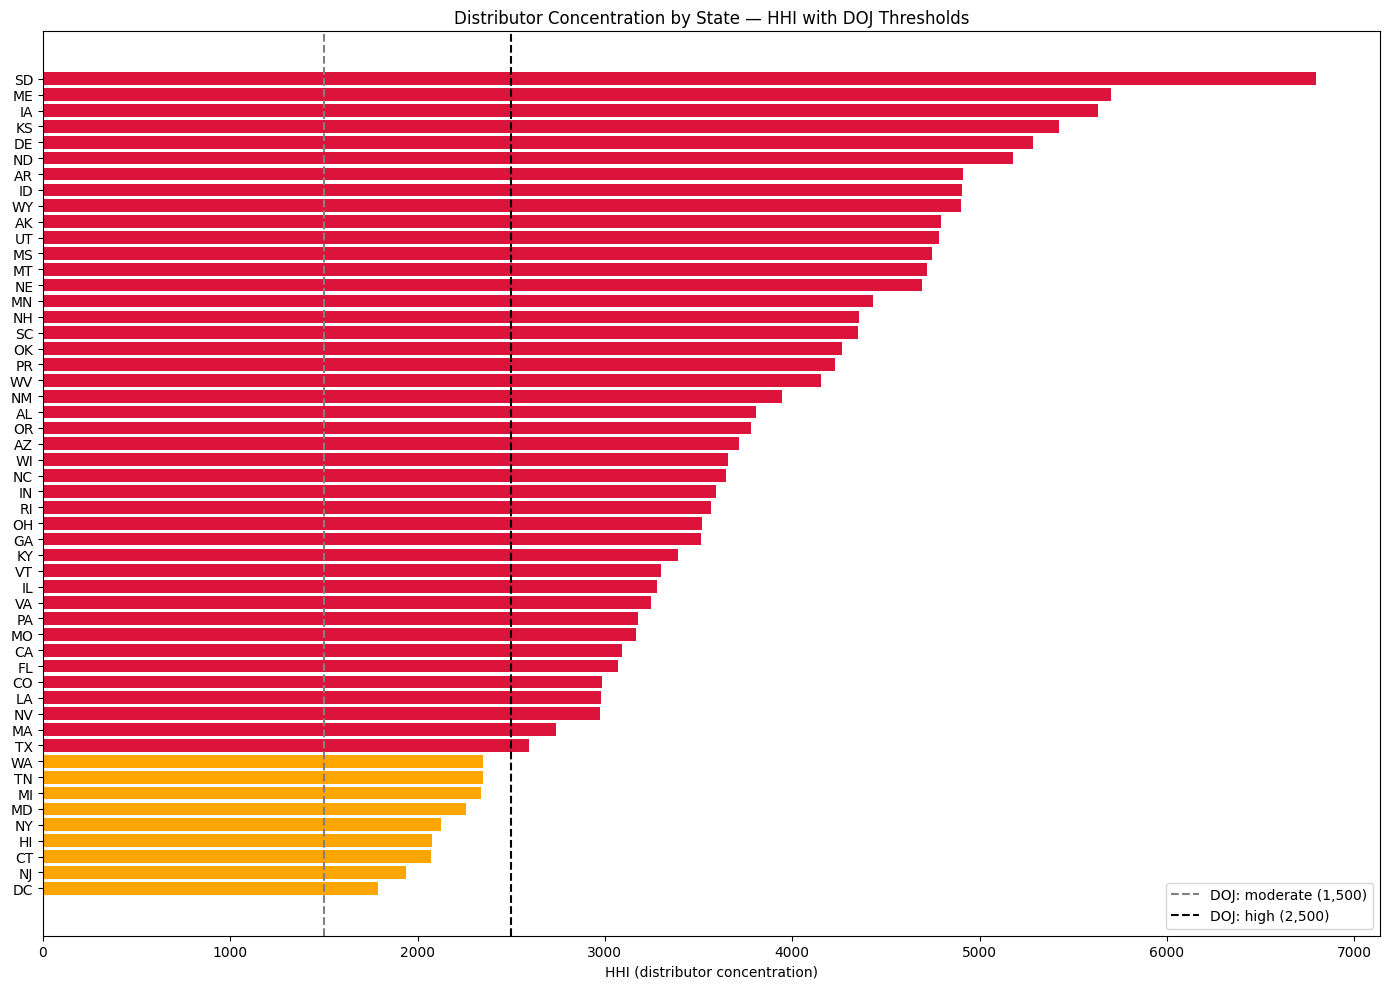

In [6]:
fig, ax = plt.subplots(figsize=(14, 10))
colors = ["crimson" if h > 2500 else "orange" if h > 1500 else "seagreen" for h in state_hhi["hhi"]]
ax.barh(state_hhi["state"], state_hhi["hhi"], color=colors)
ax.axvline(1500, color="gray", linestyle="--", label="DOJ: moderate (1,500)")
ax.axvline(2500, color="black", linestyle="--", label="DOJ: high (2,500)")
ax.invert_yaxis()
ax.set_xlabel("HHI (distributor concentration)")
ax.set_title("Distributor Concentration by State — HHI with DOJ Thresholds")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 3.3 — Category-Level Concentration

State-level HHI shows *where* concentration is high. Category-level HHI shows *in what product line*. A BEVERAGE-heavy state may be concentrated because beverages naturally flow through a few specialty distributors — that's structural, not a risk. A FOOD-heavy state concentrated in one distributor *is* a risk.

We compute HHI of distributor spend within each Category L1.


The math is identical to state-level HHI — we just `PARTITION BY category_level_1` instead of `state`. The output tells us *which product lines* are concentrated vs. diversified:

- A category with **high HHI and a specialty distributor at the top** (e.g., COFFEE → specialty coffee distributor) is often **structurally concentrated** — the product naturally flows through a narrow channel. Not necessarily a risk.
- A category with **high HHI and MASTER DISTRIBUTOR at the top** is concentration created by Aramark's channel strategy, not product structure — this is where operational risk actually sits.

Watch the `top_distributor` column below — that's the signal.


In [7]:
sql = f"""
WITH shares AS (
  SELECT
    category_level_1,
    distributor_group,
    total_spend,
    100.0 * total_spend / SUM(total_spend) OVER (PARTITION BY category_level_1) AS share_pct,
    ROW_NUMBER() OVER (PARTITION BY category_level_1 ORDER BY total_spend DESC) AS rn
  FROM {view('agg_distributor_category')}
)
SELECT
  category_level_1,
  ROUND(SUM(POW(share_pct, 2)), 0)                            AS hhi,
  ROUND(MAX(CASE WHEN rn = 1 THEN share_pct END), 2)          AS top1_share_pct,
  ANY_VALUE(CASE WHEN rn = 1 THEN distributor_group END)      AS top_distributor,
  COUNT(*)                                                    AS distributor_count,
  ROUND(SUM(total_spend), 0)                                  AS category_total_spend
FROM shares
GROUP BY category_level_1
ORDER BY hhi DESC
"""
category_hhi = client.query(sql).to_dataframe()
category_hhi


,category_level_1,hhi,top1_share_pct,top_distributor,distributor_count,category_total_spend
0,MEDICAL,6257.0,78.32,MEDICAL,26,3.184587e+07
1,FOOD,5438.0,72.85,MASTER DISTRIBUTOR,29,3.671990e+09
2,RETAIL AND PROMOTIONAL,4136.0,63.28,RETAIL,30,1.875351e+07
3,GOLF EQUIPMENT AND SUPPLIES,3958.0,48.72,GOLF EQUIPMENT & PARTS,28,6.596985e+07
4,DISPOSABLES,3900.0,60.03,MASTER DISTRIBUTOR,31,4.118346e+08
5,BEVERAGE,3763.0,45.98,DIRECT BEVERAGE,27,6.262292e+08
6,CLOTHING AND FOOTWEAR,3707.0,57.71,ROOM UNIFORMS,29,7.705460e+07
7,POOL EQUIPMENT AND SUPPLIES,3319.0,45.28,ENGINEERING MRO,23,4.844814e+06
8,ROOM AND SPA,3208.0,42.20,ROOM OPERATIONS - OTHER,28,2.321293e+08
9,FOOD SERVICE EQUIPMENT AND SUPPLIES,1907.0,36.26,SMALLWARES,29,1.549189e+08


## 3.4 — Manufacturer Concentration (Upstream Risk)

MASTER DISTRIBUTOR is a pass-through channel — it's the logistics layer, not the source of the products. Real upstream concentration sits at the **manufacturer** level. A state with diverse distributors but a single manufacturer dominating its food supply is still fragile.

**Caveat (documented).** `manufacturer_id` is ~34% missing in the raw data. We filter nulls for this analysis, which means HHI here reflects the *known* portion of the manufacturer mix. Directional conclusions are sound; exact HHI values should be read with the coverage caveat in mind.


### Manufacturer-level HHI — querying raw_spend directly

So far we've aggregated off the pre-built views. For manufacturer concentration we go back to `raw_spend` because we never built a `(state, manufacturer_id)` aggregation view. The math doesn't change — we just do the aggregation inline before applying the same HHI pattern.

**Why this matters for the risk story.** MASTER DISTRIBUTOR is a logistics pass-through — it doesn't *make* ground beef, it moves it. If manufacturer-level HHI is also high, then one genuine upstream supplier controls the category. If manufacturer-level HHI is low, the distributor concentration is an operational / logistics concern rather than a raw-supply concern.

**Caveat.** `manufacturer_id` is ~34% missing. We filter nulls, so these HHI values describe the *known* portion only. Directional comparisons across states are valid; absolute values should be read with the coverage caveat in mind.

**Two nested CTEs this time:**

1. `mfr_state` — aggregates spend at (state, manufacturer_id), filtering nulls.
2. `shares` — attaches each manufacturer's within-state share and rank.

The outer query then applies the HHI formula and extracts the top-1 manufacturer per state.


In [8]:
sql = f"""
WITH mfr_state AS (
  SELECT
    state,
    manufacturer_id,
    SUM(spend_random_factor) AS total_spend
  FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend`
  WHERE manufacturer_id IS NOT NULL
    AND state NOT IN ('GEORGIA', 'AB')
  GROUP BY state, manufacturer_id
),
shares AS (
  SELECT
    state,
    manufacturer_id,
    total_spend,
    100.0 * total_spend / SUM(total_spend) OVER (PARTITION BY state) AS share_pct,
    ROW_NUMBER() OVER (PARTITION BY state ORDER BY total_spend DESC) AS rn
  FROM mfr_state
)
SELECT
  state,
  ROUND(SUM(POW(share_pct, 2)), 0)                          AS mfr_hhi,
  ROUND(MAX(CASE WHEN rn = 1 THEN share_pct END), 2)        AS mfr_top1_share_pct,
  ANY_VALUE(CASE WHEN rn = 1 THEN manufacturer_id END)      AS top_manufacturer,
  COUNT(*)                                                  AS manufacturer_count
FROM shares
GROUP BY state
ORDER BY mfr_hhi DESC
"""
mfr_hhi = client.query(sql).to_dataframe()
mfr_hhi


,state,mfr_hhi,mfr_top1_share_pct,top_manufacturer,manufacturer_count
0,PR,5140.0,61.10,M-100680,4
1,HI,408.0,16.51,M-100479,1501
2,MT,245.0,10.96,M-100011,1280
3,ND,233.0,7.66,M-100021,964
4,VT,233.0,10.15,M-100021,1159
5,AK,228.0,9.26,M-100021,1006
6,DE,211.0,8.79,M-100003,1246
7,SD,210.0,7.83,M-100021,841
8,CT,177.0,8.27,M-100011,1712
9,AR,177.0,6.79,M-100003,1568


## 3.5 — Unified State Risk Scorecard

The final deliverable: one row per state combining distributor HHI, manufacturer HHI, top-N shares, and a risk flag. This view is the Power BI input for the Suppliers page and the single source of truth for any risk-ranking in the project.

**Risk flag logic:**
- **HIGH** — distributor HHI > 2,500 OR manufacturer HHI > 2,500 OR top-1 distributor share > 60%
- **MODERATE** — distributor HHI between 1,500 and 2,500
- **LOW** — otherwise


### Final deliverable — `agg_state_risk_scorecard`

This is the integration step. We combine distributor HHI, manufacturer HHI, and top-N shares into a single row per state and attach a three-level risk flag. This view is the Power BI input for the Suppliers page and the single source of truth for every state-risk statement we'll make in the final deliverable.

**How the SQL stitches it together:**

- **`dist_shares` + `dist_metrics`** — same pattern as cell-9, producing the distributor-side metrics.
- **`mfr_state` + `mfr_shares` + `mfr_metrics`** — same pattern as cell-14, producing `mfr_hhi`.
- **`LEFT JOIN USING(state)`** — stitches the distributor metrics to the manufacturer HHI on state. `LEFT JOIN` ensures a state missing from `mfr_metrics` (e.g., if every manufacturer was null) still keeps its distributor row.

**Risk flag — CASE WHEN cascade:**

- **HIGH** if any of: `dist_hhi > 2500`, `mfr_hhi > 2500`, or `top1_share_pct > 60`. The OR captures three distinct risk modes: distributor concentration, manufacturer concentration, and single-supplier dominance.
- **MODERATE** if `dist_hhi BETWEEN 1500 AND 2500` (and none of the HIGH triggers fired — `CASE` short-circuits).
- **LOW** otherwise.

Because `CREATE OR REPLACE VIEW` just stores the query, every future `SELECT * FROM agg_state_risk_scorecard` reruns against fresh data. If we ever reload `raw_spend`, the scorecard reflects it automatically.


In [9]:
ddl = f"""
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.agg_state_risk_scorecard` AS
WITH dist_shares AS (
  SELECT
    state,
    distributor_group,
    total_spend,
    100.0 * total_spend / SUM(total_spend) OVER (PARTITION BY state) AS share_pct,
    ROW_NUMBER() OVER (PARTITION BY state ORDER BY total_spend DESC) AS rn
  FROM {view('agg_distributor_state')}
  WHERE state NOT IN ('GEORGIA', 'AB')
),
dist_metrics AS (
  SELECT
    state,
    ROUND(SUM(POW(share_pct, 2)), 0)                       AS dist_hhi,
    ROUND(MAX(CASE WHEN rn = 1 THEN share_pct END), 2)     AS top1_share_pct,
    ROUND(SUM(CASE WHEN rn <= 3 THEN share_pct END), 2)    AS top3_share_pct,
    ANY_VALUE(CASE WHEN rn = 1 THEN distributor_group END) AS top_distributor,
    COUNT(*)                                               AS distributor_count,
    ROUND(SUM(total_spend), 0)                             AS state_total_spend
  FROM dist_shares
  GROUP BY state
),
mfr_state AS (
  SELECT state, manufacturer_id, SUM(spend_random_factor) AS total_spend
  FROM `{PROJECT_ID}.{DATASET_ID}.raw_spend`
  WHERE manufacturer_id IS NOT NULL AND state NOT IN ('GEORGIA', 'AB')
  GROUP BY state, manufacturer_id
),
mfr_shares AS (
  SELECT
    state,
    100.0 * total_spend / SUM(total_spend) OVER (PARTITION BY state) AS share_pct
  FROM mfr_state
),
mfr_metrics AS (
  SELECT state, ROUND(SUM(POW(share_pct, 2)), 0) AS mfr_hhi
  FROM mfr_shares
  GROUP BY state
)
SELECT
  d.state,
  d.state_total_spend,
  d.top_distributor,
  d.top1_share_pct,
  d.top3_share_pct,
  d.distributor_count,
  d.dist_hhi,
  m.mfr_hhi,
  CASE
    WHEN d.dist_hhi > 2500 OR m.mfr_hhi > 2500 OR d.top1_share_pct > 60 THEN 'HIGH'
    WHEN d.dist_hhi BETWEEN 1500 AND 2500                                THEN 'MODERATE'
    ELSE 'LOW'
  END AS risk_flag
FROM dist_metrics d
LEFT JOIN mfr_metrics m USING(state)
"""
client.query(ddl).result()

# Pull the scorecard
scorecard = client.query(f"SELECT * FROM {view('agg_state_risk_scorecard')} ORDER BY dist_hhi DESC").to_dataframe()
scorecard


,state,state_total_spend,top_distributor,top1_share_pct,top3_share_pct,distributor_count,dist_hhi,mfr_hhi,risk_flag
0,SD,8862852.0,MASTER DISTRIBUTOR,82.24,88.60,23,6798.0,210.0,HIGH
1,ME,13356861.0,MASTER DISTRIBUTOR,75.00,84.89,26,5701.0,137.0,HIGH
2,IA,57603780.0,MASTER DISTRIBUTOR,74.51,85.44,29,5634.0,108.0,HIGH
3,KS,29368669.0,MASTER DISTRIBUTOR,73.22,81.54,31,5425.0,137.0,HIGH
4,DE,19802666.0,MASTER DISTRIBUTOR,72.18,80.91,28,5287.0,211.0,HIGH
5,ND,9136832.0,MASTER DISTRIBUTOR,70.87,86.15,21,5181.0,233.0,HIGH
6,AR,39221886.0,MASTER DISTRIBUTOR,69.48,79.48,29,4914.0,177.0,HIGH
7,ID,23835592.0,MASTER DISTRIBUTOR,69.16,82.61,28,4906.0,139.0,HIGH
8,WY,10173341.0,MASTER DISTRIBUTOR,69.20,80.91,26,4899.0,124.0,HIGH
9,AK,11604387.0,MASTER DISTRIBUTOR,68.25,81.15,23,4792.0,228.0,HIGH


## 3.6 — Summary of Findings

### National picture — extreme concentration at the distributor layer

- **Top-1 distributor share:** 54.30% — MASTER DISTRIBUTOR alone handles more than half of all Aramark spend nationally.
- **Top-3 share:** 65.63%. **Top-5:** 74.12%. **Top-10:** 86.89%.
- Translation: the remaining **23 distributor groups combined** account for only ~13% of spend. This is textbook "long-tail" concentration — a small number of dominant players and many tiny specialty channels.
- The Lorenz curve bows sharply below the 45° equality line; the Gini coefficient (printed by cell 3.1) quantifies this inequality and confirms the visual — distributor spend is not "unequal," it's **extremely concentrated**.

### State-level concentration — every state flagged

- **42 of 52 states are HIGH risk** (HHI > 2,500); the remaining 10 are MODERATE. **Zero states register as competitive.**
- **Most concentrated states (HHI, top-1 share):**
  - SD — HHI 6,798, top-1 82.2%
  - ME — HHI 5,701, top-1 75.0%
  - IA — HHI 5,634, top-1 74.5%
  - KS — HHI 5,425, top-1 73.2%
  - DE — HHI 5,287, top-1 72.2%
- **Least concentrated (still MODERATE):** DC (1,786), NJ (1,936), CT (2,069), HI (2,078), NY (2,125).
- **Pattern:** small-spend states → fewer distributor relationships → higher HHI. SD with $8.9M total spend services through only 23 distributors (vs. 32 in CA/TX). MASTER DISTRIBUTOR fills the gap almost unilaterally in those states.
- **MASTER DISTRIBUTOR is the #1 distributor in every single US state** — uniformity that creates a systemic single-point-of-failure profile nationwide.

### Category-level concentration — structural vs. operational

- **Highly concentrated (HHI > 3,000):** MEDICAL (6,257), FOOD (5,438), RETAIL & PROMOTIONAL (4,136), GOLF EQUIPMENT (3,958), DISPOSABLES (3,900), BEVERAGE (3,763), CLOTHING & FOOTWEAR (3,707), POOL EQUIPMENT (3,319), ROOM & SPA (3,208).
- **Moderately concentrated (1,500–2,500):** FOOD SERVICE EQUIPMENT (1,907), MAINTENANCE & ENGINEERING (1,734), FURNITURE (1,708), CHEMICALS & CLEANING (1,557).
- **Structural vs operational distinction:**
  - MEDICAL → top distributor is "MEDICAL" (specialty channel for a specialty category — **structural**).
  - GOLF → "GOLF EQUIPMENT & PARTS" (**structural**, narrow product category).
  - **FOOD → MASTER DISTRIBUTOR at 72.85%** — this is the headline risk. FOOD is the largest category ($3.7B) and its concentration is a channel choice, not a product-structure necessity.
  - DISPOSABLES, CHEMICALS → also route through MASTER DISTRIBUTOR, reinforcing the central-logistics-channel pattern.

### Manufacturer concentration — the reassuring finding

- **All states except PR show manufacturer HHI below 500** — most fall in the 100–250 range, indicating a **highly diversified upstream supplier base**.
- **Top-1 manufacturer share nationwide rarely exceeds 10%**, even in the most distributor-concentrated states.
- **PR is the lone exception** (mfr HHI 5,140, top-1 61%) — only 4 manufacturers in the dataset, reflecting its tiny sample.
- **Key interpretation:** The concentration risk sits in the **logistics layer** (distributor), not the **source layer** (manufacturer). If MASTER DISTRIBUTOR fails, the products Aramark needs still exist in the market — the challenge would be re-routing, not re-sourcing. This reframes the risk as operational/continuity, not supply-chain fragility.

### Unified state risk scorecard — the deliverable

- **42 states HIGH, 10 states MODERATE, 0 states LOW.**
- The scorecard is materialized as `aramark_spend.agg_state_risk_scorecard` — directly queryable by Power BI or any downstream notebook.
- Every MODERATE state triggers on `dist_hhi` being in range. Every HIGH state triggers predominantly on `dist_hhi > 2500` or `top1_share_pct > 60`. Only PR triggers via `mfr_hhi`.

### Headline takeaways

1. **Aramark's procurement is operationally concentrated on a single distributor channel in every US state.** This is the project's #1 finding.
2. **Food is the category where this matters most** — it's the largest spend category and is 73% funneled through one pass-through distributor.
3. **The manufacturer base is diversified**, so the risk is continuity-of-operations, not supply-of-goods.
4. **Small states have less flexibility** — they service through fewer distributor relationships, making them disproportionately exposed to a MASTER DISTRIBUTOR disruption.
